<a href="https://colab.research.google.com/github/MohitVerma0098/6thSem-ML-Lab/blob/main/ML_LAB_EXAM_1BM23CS198.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter CSV path (default: data.csv): /mnt/Mall_Customers.csv

✅ Loaded: 200 rows × 5 columns

🔵 Handling Missing Values:
No missing values in 'CustomerID'
No missing values in 'Gender'
No missing values in 'Age'
No missing values in 'Annual Income (k$)'
No missing values in 'Spending Score (1-100)'

🔵 Encoding Categorical Features:
Encoded 'Gender'

Available features:
CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)

Enter features for clustering (comma-separated): Annual Income (k$), Spending Score (1-100)

✅ Using features: ['Annual Income (k$)', 'Spending Score (1-100)']

Enter number of clusters K (default 3): 

🔵 K-Means Results
Clusters         : 3
Inertia (WCSS)   : 157.7040
Silhouette Score : 0.4666

📊 Cluster Characteristics:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0             162.0  0.526316  40.394737           87.000000   
1             162.0  0.461538  32.692308    

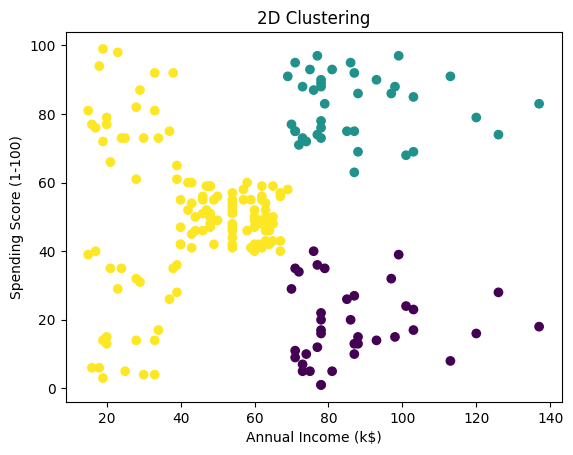

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ==============================
# LOAD DATA
# ==============================
path = input("Enter CSV path (default: data.csv): ").strip()
if path == "":
    path = "data.csv"

df = pd.read_csv(path)
print(f"\n✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# ==============================
# HANDLE MISSING VALUES
# ==============================
print("\n🔵 Handling Missing Values:")
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"Filled missing categorical in '{col}'")
        else:
            df[col].fillna(df[col].mean(), inplace=True)
            print(f"Filled missing numeric in '{col}'")
    else:
        print(f"No missing values in '{col}'")

# ==============================
# ENCODE CATEGORICAL FEATURES
# ==============================
print("\n🔵 Encoding Categorical Features:")
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded '{col}'")

# ==============================
# FEATURE SELECTION
# ==============================
print("\nAvailable features:")
print(", ".join(df.columns))

features_input = input(
    "\nEnter features for clustering (comma-separated): "
).strip()

selected_features = [f.strip() for f in features_input.split(",")]

# Validate columns
valid_features = []
for f in selected_features:
    if f in df.columns:
        valid_features.append(f)
    else:
        print(f"⚠️ Column '{f}' not found — skipped")

if len(valid_features) == 0:
    raise ValueError("❌ No valid columns selected.")

print(f"\n✅ Using features: {valid_features}")

X = df[valid_features]

# ==============================
# SCALING
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# K-MEANS
# ==============================
k = input("\nEnter number of clusters K (default 3): ").strip()
k = int(k) if k else 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# ==============================
# METRICS
# ==============================
print("\n🔵 K-Means Results")
print("=" * 40)
print(f"Clusters         : {k}")
print(f"Inertia (WCSS)   : {kmeans.inertia_:.4f}")

if k > 1:
    score = silhouette_score(X_scaled, clusters)
    print(f"Silhouette Score : {score:.4f}")

# ==============================
# CLUSTER CHARACTERISTICS
# ==============================
print("\n📊 Cluster Characteristics:")

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

# ==============================
# VISUALIZATION
# ==============================
if len(valid_features) == 1:
    # 1D Plot
    plt.scatter(df[valid_features[0]], np.zeros_like(df[valid_features[0]]),
                c=clusters, cmap='viridis')
    plt.xlabel(valid_features[0])
    plt.title("1D Clustering")
    plt.show()

elif len(valid_features) == 2:
    # 2D Plot
    plt.scatter(df[valid_features[0]], df[valid_features[1]],
                c=clusters, cmap='viridis')
    plt.xlabel(valid_features[0])
    plt.ylabel(valid_features[1])
    plt.title("2D Clustering")
    plt.show()

else:
    print("\n⚠️ Visualization only supported for 1 or 2 features.")
